### Modelo de Regresión Lineal Múltiple para la Estimación de Gastos Médicos

#### Cynthia Cuñez

##### Repositorio: https://github.com/cynthia0206/pruebamaquinas2/blob/main/PRUEBA.ipynb

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
import kagglehub

In [24]:
# Descargar y cargar el dataset desde Kaggle

ruta_dataset = kagglehub.dataset_download("mirichoi0218/insurance")

archivo_csv = None

for raiz, carpetas, archivos in os.walk(ruta_dataset):
    if "insurance.csv" in archivos:
        archivo_csv = os.path.join(raiz, "insurance.csv")
        break

df = pd.read_csv(archivo_csv)

print("Dataset cargado correctamente.")
print(df.head())

Dataset cargado correctamente.
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


#### DESARROLLO 

### CARGA Y COMPRENSIÓN DE LOS DATOS

In [26]:
# Mostrar cantidad de filas y columnas

print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 1338
Número de columnas: 7


In [21]:
# Nombres de las columnas
print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [22]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### EDA y calidad de los datos 

In [25]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [27]:
# Verificar registros duplicados
print("Cantidad de registros duplicados:", df.duplicated().sum())

Cantidad de registros duplicados: 1


In [28]:
# Mostrar los tipos de datos
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


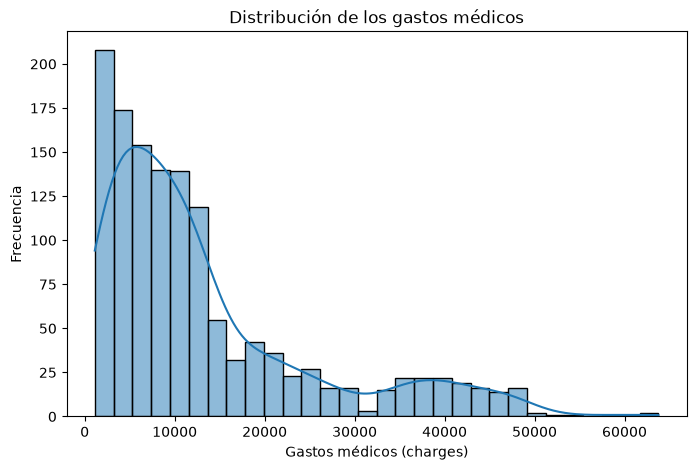

In [29]:
# Distribución de los gastos médicos
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribución de los gastos médicos")
plt.xlabel("Gastos médicos (charges)")
plt.ylabel("Frecuencia")

plt.show()

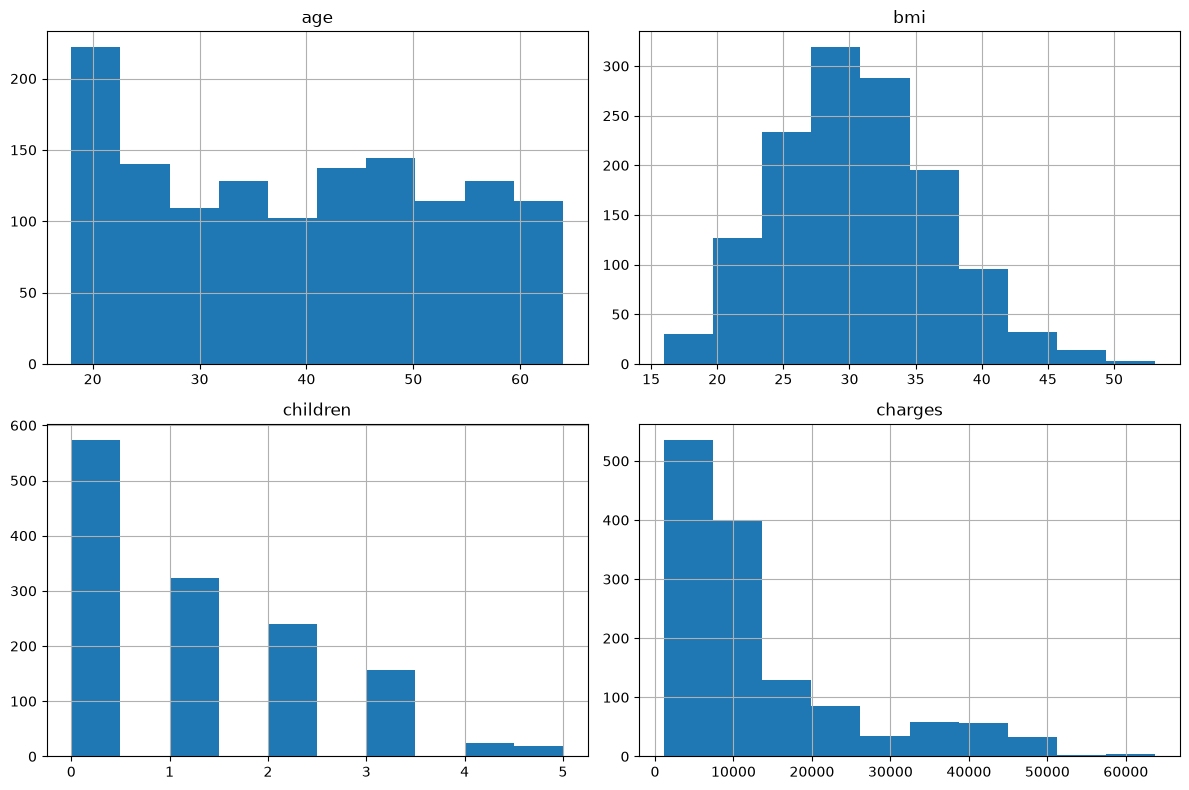

In [30]:
# Histogramas de las variables numéricas
df.hist(figsize=(12,8))

plt.tight_layout()
plt.show()

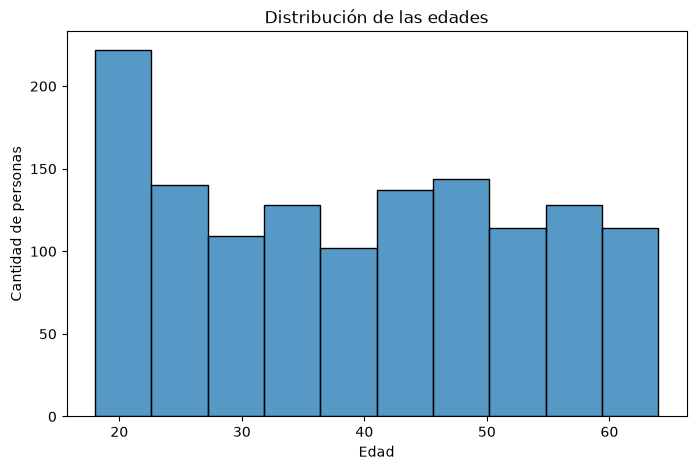

In [34]:
# Distribución de las edades
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="age", bins=10)

plt.title("Distribución de las edades")
plt.xlabel("Edad")
plt.ylabel("Cantidad de personas")

plt.show()

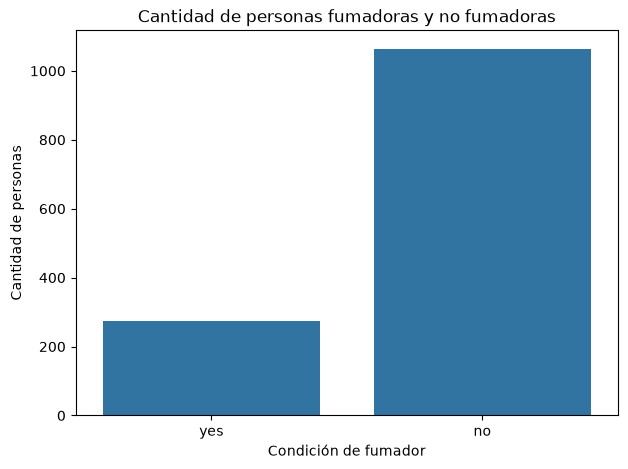

In [33]:
# Cantidad de personas según condición de fumador
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="smoker")

plt.title("Cantidad de personas fumadoras y no fumadoras")
plt.xlabel("Condición de fumador")
plt.ylabel("Cantidad de personas")

plt.show()

### Detección de outliers

In [40]:
# Función para detectar outliers

def find_outliers(df, algorithm):
    outlier_method = algorithm.fit(df)
    
    # Aplicamos el método de detección
    df_outliers = outlier_method.predict(df)
    
    print(df_outliers)
    
    # Determinamos la posición de los outliers
    pos_outliers = np.where(df_outliers == -1)[0]
    
    print("\nOutliers en la posición:\n", pos_outliers)
    
    # Determinamos el número de outliers
    print("\nNúmero de outliers:\n", len(pos_outliers))
    
    return df_outliers, pos_outliers

In [36]:
from sklearn.ensemble import IsolationForest

In [41]:
# Seleccionamos las variables numéricas
df_numerico = df[["age", "bmi", "children", "charges"]]

In [42]:
# Definimos el algoritmo Isolation Forest
IF = IsolationForest(
    contamination=0.05,
    random_state=42
)
# Detectamos los outliers
df_outliers, pos_outliers = find_outliers(df_numerico, IF)

[1 1 1 ... 1 1 1]

Outliers en la posición:
 [  32   34   39   71   94  109  128  166  175  185  250  251  265  281
  292  321  328  344  413  420  425  438  480  488  494  530  543  549
  568  577  621  640  674  677  725  738  803  819  847  860  877  901
  932  937  951  969  984 1012 1021 1047 1062 1085 1095 1124 1130 1146
 1156 1186 1230 1240 1241 1245 1272 1300 1301 1317 1318]

Número de outliers:
 67


### Preparación de variables 

In [57]:
# Preparación de variables

X = df.drop("charges", axis=1)
y = df["charges"]

variables_numericas = ["age", "bmi", "children"]
variables_categoricas = ["sex", "smoker", "region"]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

print("\nVariables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables predictoras:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Variable objetivo:
charges

Variables numéricas:
['age', 'bmi', 'children']

Variables categóricas:
['sex', 'smoker', 'region']


In [58]:
# Transformación de variables categóricas

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_categoricas_transformadas = encoder.fit_transform(
    df[variables_categoricas]
)

print("\nVariables categóricas transformadas:")
print(X_categoricas_transformadas[:5])

print("\nDimensiones:")
print(X_categoricas_transformadas.shape)


Variables categóricas transformadas:
[[1. 0. 0. 1. 0. 0. 0. 1.]
 [0. 1. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 0. 1. 0. 0.]
 [0. 1. 1. 0. 0. 1. 0. 0.]]

Dimensiones:
(1338, 8)


#### Normalización o estandarización 

In [59]:
# Estandarizar las variables numéricas

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_estandarizado = scaler.fit_transform(df[variables_numericas])

print("Variables numéricas estandarizadas:")
print(X_estandarizado[:5])

print("\nMedia:")
print(X_estandarizado.mean(axis=0))

print("\nDesviación estándar:")
print(X_estandarizado.std(axis=0))

Variables numéricas estandarizadas:
[[-1.43876426 -0.45332    -0.90861367]
 [-1.50996545  0.5096211  -0.07876719]
 [-0.79795355  0.38330685  1.58092576]
 [-0.4419476  -1.30553108 -0.90861367]
 [-0.51314879 -0.29255641 -0.90861367]]

Media:
[-1.80556450e-16 -2.12419353e-16 -5.57600802e-17]

Desviación estándar:
[1. 1. 1.]


### Selección de atributos

In [61]:
# Unir las variables numéricas y categóricas preparadas

X_preparado = np.hstack([
    X_estandarizado,
    X_categoricas
])

print("Dimensiones de los datos preparados:")
print(X_preparado.shape)

Dimensiones de los datos preparados:
(1338, 11)


In [67]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(
    score_func=f_regression,
    k=8
)

X_seleccionado = selector.fit_transform(
    X_preparado,
    y
)

print("Dimensiones antes de la selección:")
print(X_preparado.shape)

print("\nDimensiones después de la selección:")
print(X_seleccionado.shape)

Dimensiones antes de la selección:
(1338, 11)

Dimensiones después de la selección:
(1338, 8)


In [66]:
atributos_seleccionados = [
    nombres_atributos[i]
    for i in range(len(nombres_atributos))
    if seleccionados[i]
]

print("Atributos seleccionados:")
for atributo in atributos_seleccionados:
    print("-", atributo)

Atributos seleccionados:
- age
- bmi
- children
- sex_female
- sex_male
- smoker_no
- smoker_yes
- region_southeast


#### Validación de datos 

In [68]:
# 80% para entrenamiento y 20% para prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seleccionado,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1070, 8)
Datos de prueba: (268, 8)


#### Entrenamiento mediante Regresión Lineal 

In [70]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

print("Modelo de Regresión Lineal entrenado correctamente.")

Modelo de Regresión Lineal entrenado correctamente.


#### Evaluación

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 4200.069552933788
MSE: 33816742.790843286
RMSE: 5815.21648701433
R²: 0.7821770106209518


### Predicción de datos 

In [74]:
# Nuevo paciente
nuevo_dato = pd.DataFrame({
    "age": [30],
    "sex": ["male"],
    "bmi": [25],
    "children": [1],
    "smoker": ["no"],
    "region": ["northeast"]
})

# Estandarizar variables numéricas
nuevo_numerico = scaler.transform(
    nuevo_dato[variables_numericas]
)

# Transformar variables categóricas
nuevo_categorico = encoder.transform(
    nuevo_dato[variables_categoricas]
)

# Unir las variables
nuevo_preparado = np.hstack([
    nuevo_numerico,
    nuevo_categorico
])

# Aplicar la selección de atributos
nuevo_seleccionado = selector.transform(
    nuevo_preparado
)

# Realizar la predicción
prediccion = modelo.predict(nuevo_seleccionado)

print("Gasto médico estimado:", prediccion[0])

Gasto médico estimado: 4245.341799005109
